In [2]:
print('Radha!')

Radha!


In [3]:
from typing import TypedDict

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

load_dotenv()

True

In [4]:
# -----------------------------
# LLM
# -----------------------------

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

In [5]:
# -----------------------------
# STATE
# -----------------------------

class State(TypedDict):
    text: str
    summary: str
    keywords: str
    sentiment: str
    final_report: str

In [6]:
# -----------------------------
# PARALLEL NODES
# -----------------------------

def summarize(state: State):
     response = llm.invoke(
        f"Summarize the following text in 3-4 sentences:\n\n{state['text']}"
     )

     return {
            "summary": response.content
         }

def extract_keywords(state: State):
    response = llm.invoke(
        f"Extract the 5 most important keywords from this text:\n\n{state['text']}"
    )

    return {
        "keywords": response.content
    }

def analyze_sentiment(state: State):
    response = llm.invoke(
        f"Analyze the sentiment of this text as Positive, Negative, or Neutral. Explain briefly.\n\n{state['text']}"
    )

    return {
        "sentiment": response.content
    }


In [7]:
# -----------------------------
# COMBINER NODE
# -----------------------------
def combine(state: State):

    report = f"""
CONTENT ANALYSIS REPORT

Summary:
{state['summary']}

Keywords:
{state['keywords']}

Sentiment:
{state['sentiment']}
"""

    return {
        "final_report": report
    }

In [8]:
# -----------------------------
# GRAPH
# -----------------------------

graph = StateGraph(State)

graph.add_node("summarize", summarize)
graph.add_node("keywords", extract_keywords)
graph.add_node("sentiment", analyze_sentiment)
graph.add_node("combine", combine)


In [9]:
# Fan-out (parallel)

graph.add_edge(START, "summarize")
graph.add_edge(START, "keywords")
graph.add_edge(START, "sentiment")

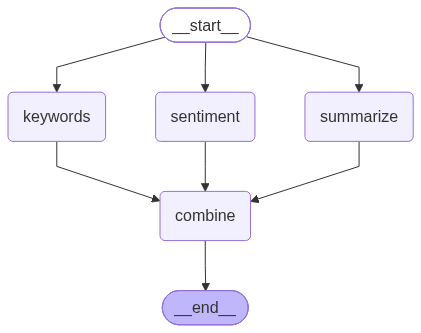

In [10]:
# Fan-in (join)

graph.add_edge("summarize", "combine")
graph.add_edge("keywords", "combine")
graph.add_edge("sentiment", "combine")

graph.add_edge("combine", END)


app = graph.compile()
app

In [11]:
# -----------------------------
# RUN
# -----------------------------


text = """I recently upgraded to the Apex Wireless Headphones, 
and the active noise cancellation is fantastic for my daily bus commute. 
The sound quality is rich with punchy bass, and the battery easily lasts two days. 
However, the companion mobile app feels outdated and crashed twice while I was adjusting the equalizer settings. 
Overall, it is a solid purchase despite the software bugs."""

result = app.invoke({
        "text": text
    })

print(result["final_report"])


CONTENT ANALYSIS REPORT

Summary:
The Apex Wireless Headphones offer excellent active noise cancellation, making them ideal for daily commutes. They deliver rich sound quality with strong bass and have a long battery life of up to two days. However, the companion mobile app is outdated and has crashed twice while adjusting equalizer settings. Despite these software issues, the headphones are still considered a solid purchase.

Keywords:
1. Apex Wireless Headphones
2. Active noise cancellation
3. Sound quality
4. Battery life
5. Companion mobile app

Sentiment:
The sentiment of the text is **Positive**. 

The reviewer expresses satisfaction with several key features of the Apex Wireless Headphones, such as the fantastic active noise cancellation, rich sound quality, and long battery life. These positive aspects outweigh the mention of the outdated companion app and its crashes, which are acknowledged as drawbacks but do not significantly detract from the overall positive impression. Th

In [20]:
text = """I recently upgraded to the Apex Wireless Headphones, 
and the active noise cancellation is fantastic for my daily bus commute. 
The sound quality is rich with punchy bass, and the battery easily lasts two days. 
However, the companion mobile app feels outdated and crashed twice while I was adjusting the equalizer settings. 
Overall, it is a solid purchase despite the software bugs."""

results = app.stream({
        "text": text
    })

for result in results:
    print(result)

{'keywords': {'keywords': '1. Apex Wireless Headphones\n2. Active noise cancellation\n3. Sound quality\n4. Battery life\n5. Companion mobile app'}}
{'sentiment': {'sentiment': 'The sentiment of the text is **Positive**. \n\nThe reviewer expresses satisfaction with several key features of the Apex Wireless Headphones, such as the fantastic active noise cancellation, rich sound quality, and long battery life. These positive aspects contribute to an overall favorable impression. Although the reviewer mentions a negative experience with the companion mobile app, they still conclude that it is a "solid purchase," indicating that the positives outweigh the negatives. This balance of praise and minor criticism leads to an overall positive sentiment.'}}
{'summarize': {'summary': 'The Apex Wireless Headphones offer excellent active noise cancellation, making them ideal for daily commutes. They deliver rich sound quality with strong bass, and the battery life lasts up to two days. However, the c

In [22]:
text = """I recently upgraded to the Apex Wireless Headphones, 
and the active noise cancellation is fantastic for my daily bus commute. 
The sound quality is rich with punchy bass, and the battery easily lasts two days. 
However, the companion mobile app feels outdated and crashed twice while I was adjusting the equalizer settings. 
Overall, it is a solid purchase despite the software bugs."""

results = app.stream({
        "text": text
    })


for result in results:
    for key, content in result.items():
        print(key, ":", list(content.values())[0])

keywords : 1. Apex Wireless Headphones
2. Active noise cancellation
3. Sound quality
4. Battery life
5. Companion mobile app
summarize : The Apex Wireless Headphones offer excellent active noise cancellation, making them ideal for daily commutes. They deliver rich sound quality with strong bass, and the battery life lasts up to two days. However, the companion mobile app is outdated and has crashed twice while adjusting equalizer settings. Despite these software issues, the headphones are still considered a solid purchase.
sentiment : The sentiment of the text is **Positive**. 

The reviewer expresses satisfaction with several key features of the Apex Wireless Headphones, such as the fantastic active noise cancellation, rich sound quality, and long battery life. These positive aspects outweigh the mention of the outdated companion app and its crashes, which are acknowledged as drawbacks but do not significantly diminish the overall positive impression. The concluding statement, "Overal

In [23]:
text = """I recently upgraded to the Apex Wireless Headphones, 
and the active noise cancellation is fantastic for my daily bus commute. 
The sound quality is rich with punchy bass, and the battery easily lasts two days. 
However, the companion mobile app feels outdated and crashed twice while I was adjusting the equalizer settings. 
Overall, it is a solid purchase despite the software bugs."""

results = app.stream({
        "text": text
    })

for result in results:
    for key, content in result.items():
        print(key, ":", list(content.values())[0])

keywords : 1. Apex Wireless Headphones
2. Active noise cancellation
3. Sound quality
4. Battery life
5. Companion mobile app
summarize : The Apex Wireless Headphones offer excellent active noise cancellation, making them ideal for daily commutes. They deliver rich sound quality with strong bass and have a long battery life of up to two days. However, the companion mobile app is outdated and has crashed twice while adjusting settings. Despite these software issues, the headphones are still considered a solid purchase.
sentiment : The sentiment of the text is **Positive**. 

The reviewer expresses satisfaction with several key features of the Apex Wireless Headphones, such as the fantastic active noise cancellation, rich sound quality, and long battery life. These positive aspects contribute to an overall favorable impression. Although the reviewer mentions a negative experience with the companion mobile app, they still conclude that it is a "solid purchase," indicating that the positive